# Project #4: FEMA NRI Sensitivity Analysis
## CIVE 202 – Civil Engineering Analysis II
**Prepared by:** Mina Awad, Ava Johnson, Elizabeth Wiggins  
**Submitted to:** Dr. Kaycie Lane, P.E. — University of Nebraska–Omaha  
**Date:** April 21, 2026

**States Analyzed:** California and Colorado  
**Alternative Risk Formula:** Alt Risk Score = 0.6 × EAL_SPCTL + 0.4 × (RPL_THEMES × 100)

## Section 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Uncomment below if running GeoPandas maps
import geopandas as gpd

## Section 2: Load Data

In [3]:
# Load NRI Census Tract data for both states
nri_ca = pd.read_csv('NRI_Table_CensusTracts_California.csv', low_memory=False)
nri_co = pd.read_csv('NRI_Table_CensusTracts_Colorado.csv', low_memory=False)

# Load ATSDR Social Vulnerability Index (SVI) data
svi_ca = pd.read_csv('California.csv', low_memory=False)
svi_co = pd.read_csv('Colorado.csv', low_memory=False)

# Load NRI County-level data for comparison
county_ca = pd.read_csv('NRI_Table_Counties_California.csv', low_memory=False)
county_co = pd.read_csv('NRI_Table_Counties_Colorado.csv', low_memory=False)

print(f"NRI California Census Tracts: {nri_ca.shape[0]} rows, {nri_ca.shape[1]} columns")
print(f"NRI Colorado Census Tracts:   {nri_co.shape[0]} rows, {nri_co.shape[1]} columns")
print(f"SVI California:               {svi_ca.shape[0]} rows, {svi_ca.shape[1]} columns")
print(f"SVI Colorado:                 {svi_co.shape[0]} rows, {svi_co.shape[1]} columns")
print(f"County California:            {county_ca.shape[0]} rows, {county_ca.shape[1]} columns")
print(f"County Colorado:              {county_co.shape[0]} rows, {county_co.shape[1]} columns")

NRI California Census Tracts: 9106 rows, 467 columns
NRI Colorado Census Tracts:   1447 rows, 467 columns
SVI California:               9109 rows, 158 columns
SVI Colorado:                 1447 rows, 158 columns
County California:            58 rows, 465 columns
County Colorado:              64 rows, 465 columns


## Section 3: Data Exploration

In [4]:
# Inspect key NRI columns
key_cols = ['TRACTFIPS', 'STATE', 'COUNTY', 'RISK_SCORE', 'RISK_RATNG',
            'RISK_SPCTL', 'EAL_SCORE', 'EAL_SPCTL', 'SOVI_SPCTL',
            'RESL_SPCTL', 'POPULATION', 'BUILDVALUE']

print("=== California NRI Sample ===")
print(nri_ca[key_cols].head())
print(f"\nEAL_SPCTL range: {nri_ca['EAL_SPCTL'].min():.2f} to {nri_ca['EAL_SPCTL'].max():.2f}")
print(f"\n=== NRI Risk Rating Distribution (California) ===")
print(nri_ca['RISK_RATNG'].value_counts())

=== California NRI Sample ===
    TRACTFIPS       STATE   COUNTY  RISK_SCORE           RISK_RATNG  \
0  6001400100  California  Alameda   93.950673      Relatively High   
1  6001400200  California  Alameda   82.478714  Relatively Moderate   
2  6001400300  California  Alameda   93.655758      Relatively High   
3  6001400400  California  Alameda   85.304191      Relatively High   
4  6001400500  California  Alameda   80.513010  Relatively Moderate   

   RISK_SPCTL  EAL_SCORE  EAL_SPCTL  SOVI_SPCTL  RESL_SPCTL  POPULATION  \
0   82.528004  98.271367  94.553042    0.009554    0.919174        3038   
1   55.183396  86.934260  68.317593    0.177575    0.919174        1995   
2   81.814188  94.152946  85.009884    0.384142    0.919174        5504   
3   61.816385  89.346361  73.973204    0.172743    0.919174        4112   
4   50.845596  85.765789  65.550187    0.154404    0.919174        3644   

     BUILDVALUE  
0  1.277580e+09  
1  5.261868e+08  
2  9.030828e+08  
3  6.635660e+08  
4 

In [5]:
# Inspect SVI columns
svi_cols = ['FIPS', 'STATE', 'COUNTY', 'RPL_THEMES',
            'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4']

print("=== California SVI Sample ===")
print(svi_ca[svi_cols].head())
print(f"\nRPL_THEMES range: {svi_ca['RPL_THEMES'].min()} to {svi_ca['RPL_THEMES'].max()}")
print(f"Tracts with -999 sentinel (CA): {(svi_ca['RPL_THEMES'] == -999).sum()}")
print(f"Tracts with -999 sentinel (CO): {(svi_co['RPL_THEMES'] == -999).sum()}")

=== California SVI Sample ===
         FIPS       STATE          COUNTY  RPL_THEMES  RPL_THEME1  RPL_THEME2  \
0  6001400100  California  Alameda County      0.1598      0.0527      0.5783   
1  6001400200  California  Alameda County      0.1827      0.1008      0.1454   
2  6001400300  California  Alameda County      0.2366      0.1872      0.1687   
3  6001400400  California  Alameda County      0.1451      0.0581      0.1609   
4  6001400500  California  Alameda County      0.2148      0.4501      0.0408   

   RPL_THEME3  RPL_THEME4  
0      0.1340      0.2353  
1      0.1261      0.5632  
2      0.2432      0.5062  
3      0.1865      0.4582  
4      0.4302      0.2419  

RPL_THEMES range: -999.0 to 1.0
Tracts with -999 sentinel (CA): 68
Tracts with -999 sentinel (CO): 16


## Section 4: Data Cleaning and Merging

In [5]:
# Select SVI columns needed for merge
svi_ca_merge = svi_ca[['FIPS', 'RPL_THEMES', 'RPL_THEME1',
                        'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4']].copy()
svi_co_merge = svi_co[['FIPS', 'RPL_THEMES', 'RPL_THEME1',
                        'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4']].copy()

# Merge NRI with SVI on Census Tract FIPS code
merged_ca = nri_ca.merge(svi_ca_merge, left_on='TRACTFIPS', right_on='FIPS',
                         how='left', suffixes=('', '_SVI'))
merged_co = nri_co.merge(svi_co_merge, left_on='TRACTFIPS', right_on='FIPS',
                         how='left', suffixes=('', '_SVI'))

print(f"California merged: {merged_ca.shape[0]} tracts ({merged_ca.shape[1]} columns)")
print(f"Colorado merged:   {merged_co.shape[0]} tracts ({merged_co.shape[1]} columns)")
print(f"Unmatched CA: {merged_ca['RPL_THEMES'].isna().sum()}")
print(f"Unmatched CO: {merged_co['RPL_THEMES'].isna().sum()}")

California merged: 9106 tracts (473 columns)
Colorado merged:   1447 tracts (473 columns)
Unmatched CA: 0
Unmatched CO: 0


In [6]:
# Replace -999 sentinel values with NaN
svi_theme_cols = ['RPL_THEMES', 'RPL_THEME1', 'RPL_THEME2',
                  'RPL_THEME3', 'RPL_THEME4']

for col in svi_theme_cols:
    merged_ca.loc[merged_ca[col] == -999, col] = np.nan
    merged_co.loc[merged_co[col] == -999, col] = np.nan

ca_missing = merged_ca['RPL_THEMES'].isna().sum()
co_missing = merged_co['RPL_THEMES'].isna().sum()
print(f"CA tracts with missing RPL_THEMES after cleaning: {ca_missing}")
print(f"CO tracts with missing RPL_THEMES after cleaning: {co_missing}")

# Filter to valid tracts only
ca_valid = merged_ca.dropna(subset=['RPL_THEMES', 'EAL_SPCTL']).copy()
co_valid = merged_co.dropna(subset=['RPL_THEMES', 'EAL_SPCTL']).copy()
print(f"\nValid tracts for analysis: CA = {len(ca_valid)}, CO = {len(co_valid)}")

CA tracts with missing RPL_THEMES after cleaning: 65
CO tracts with missing RPL_THEMES after cleaning: 16

Valid tracts for analysis: CA = 9041, CO = 1431


## Section 5: Alternative Risk Score Calculation

**Formula:** Alternative Risk Score = 0.6 × EAL_SPCTL + 0.4 × (RPL_THEMES × 100)

- EAL_SPCTL (0–100): NRI Expected Annual Loss state percentile
- RPL_THEMES (0–1): ATSDR SVI overall percentile, scaled by 100
- Weight 0.6 on hazard exposure, 0.4 on social vulnerability
- Scores ranked into within-state percentiles and classified using FEMA breakpoints

In [7]:
# Calculate alternative risk score
ca_valid['ALT_RISK_SCORE'] = (0.6 * ca_valid['EAL_SPCTL']
                              + 0.4 * (ca_valid['RPL_THEMES'] * 100))
co_valid['ALT_RISK_SCORE'] = (0.6 * co_valid['EAL_SPCTL']
                              + 0.4 * (co_valid['RPL_THEMES'] * 100))

# Rank into within-state percentiles
ca_valid['ALT_RISK_PCTL'] = ca_valid['ALT_RISK_SCORE'].rank(pct=True) * 100
co_valid['ALT_RISK_PCTL'] = co_valid['ALT_RISK_SCORE'].rank(pct=True) * 100

# Classify into qualitative categories using FEMA breakpoints
def classify_risk(pctl):
    if pctl <= 20:
        return "Very Low"
    elif pctl <= 40:
        return "Relatively Low"
    elif pctl <= 60:
        return "Relatively Moderate"
    elif pctl <= 80:
        return "Relatively High"
    else:
        return "Very High"

ca_valid['ALT_RISK_RATNG'] = ca_valid['ALT_RISK_PCTL'].apply(classify_risk)
co_valid['ALT_RISK_RATNG'] = co_valid['ALT_RISK_PCTL'].apply(classify_risk)

print("=== Alternative Risk Score Summary ===")
print(f"CA range: {ca_valid['ALT_RISK_SCORE'].min():.2f} to "
      f"{ca_valid['ALT_RISK_SCORE'].max():.2f}")
print(f"CO range: {co_valid['ALT_RISK_SCORE'].min():.2f} to "
      f"{co_valid['ALT_RISK_SCORE'].max():.2f}")
print(f"\n=== Alternative Rating Distribution ===")
print("California:", ca_valid['ALT_RISK_RATNG'].value_counts().to_dict())
print("Colorado:  ", co_valid['ALT_RISK_RATNG'].value_counts().to_dict())

=== Alternative Risk Score Summary ===
CA range: 0.32 to 98.36
CO range: 1.33 to 97.70

=== Alternative Rating Distribution ===
California: {'Very High': 1809, 'Relatively High': 1808, 'Relatively Moderate': 1808, 'Very Low': 1808, 'Relatively Low': 1808}
Colorado:   {'Very High': 287, 'Relatively High': 286, 'Relatively Moderate': 286, 'Relatively Low': 286, 'Very Low': 286}


## Section 6: Summary Tables — NRI vs. Alternative Cross-Tabulation

In [8]:
# Define rating order for consistent display
rating_order = ["Very Low", "Relatively Low", "Relatively Moderate",
                "Relatively High", "Very High"]

# California cross-tabulation
ca_xtab = pd.crosstab(
    ca_valid['RISK_RATNG'],
    ca_valid['ALT_RISK_RATNG'],
    margins=True,
    margins_name='Total'
)
ca_xtab = ca_xtab.reindex(
    index=rating_order + ['Total'],
    columns=rating_order + ['Total'],
    fill_value=0
)

print("=== Table 1: California — NRI vs. Alternative Rating ===")
print(ca_xtab)

# Agreement statistics
ca_agree = (ca_valid['RISK_RATNG'] == ca_valid['ALT_RISK_RATNG']).sum()
print(f"\nExact agreement: {ca_agree}/{len(ca_valid)} "
      f"({ca_agree/len(ca_valid)*100:.1f}%)")

=== Table 1: California — NRI vs. Alternative Rating ===
ALT_RISK_RATNG       Very Low  Relatively Low  Relatively Moderate  \
RISK_RATNG                                                           
Very Low                  427              23                    0   
Relatively Low           1157             527                   35   
Relatively Moderate       224            1257                 1440   
Relatively High             0               1                  333   
Very High                   0               0                    0   
Total                    1808            1808                 1808   

ALT_RISK_RATNG       Relatively High  Very High  Total  
RISK_RATNG                                              
Very Low                           0          0    450  
Relatively Low                     0          0   1719  
Relatively Moderate              484          1   3406  
Relatively High                 1215       1081   2630  
Very High                        109    

In [9]:
# Colorado cross-tabulation
co_xtab = pd.crosstab(
    co_valid['RISK_RATNG'],
    co_valid['ALT_RISK_RATNG'],
    margins=True,
    margins_name='Total'
)
co_xtab = co_xtab.reindex(
    index=rating_order + ['Total'],
    columns=rating_order + ['Total'],
    fill_value=0
)

print("=== Table 2: Colorado — NRI vs. Alternative Rating ===")
print(co_xtab)

co_agree = (co_valid['RISK_RATNG'] == co_valid['ALT_RISK_RATNG']).sum()
print(f"\nExact agreement: {co_agree}/{len(co_valid)} "
      f"({co_agree/len(co_valid)*100:.1f}%)")

=== Table 2: Colorado — NRI vs. Alternative Rating ===
ALT_RISK_RATNG       Very Low  Relatively Low  Relatively Moderate  \
RISK_RATNG                                                           
Very Low                  276             133                    7   
Relatively Low             10             153                  274   
Relatively Moderate         0               0                    5   
Relatively High             0               0                    0   
Very High                   0               0                    0   
Total                     286             286                  286   

ALT_RISK_RATNG       Relatively High  Very High  Total  
RISK_RATNG                                              
Very Low                           0          0    416  
Relatively Low                   185         39    661  
Relatively Moderate               93        195    293  
Relatively High                    8         50     58  
Very High                          0      

## Section 7: Figures — Visual Comparison

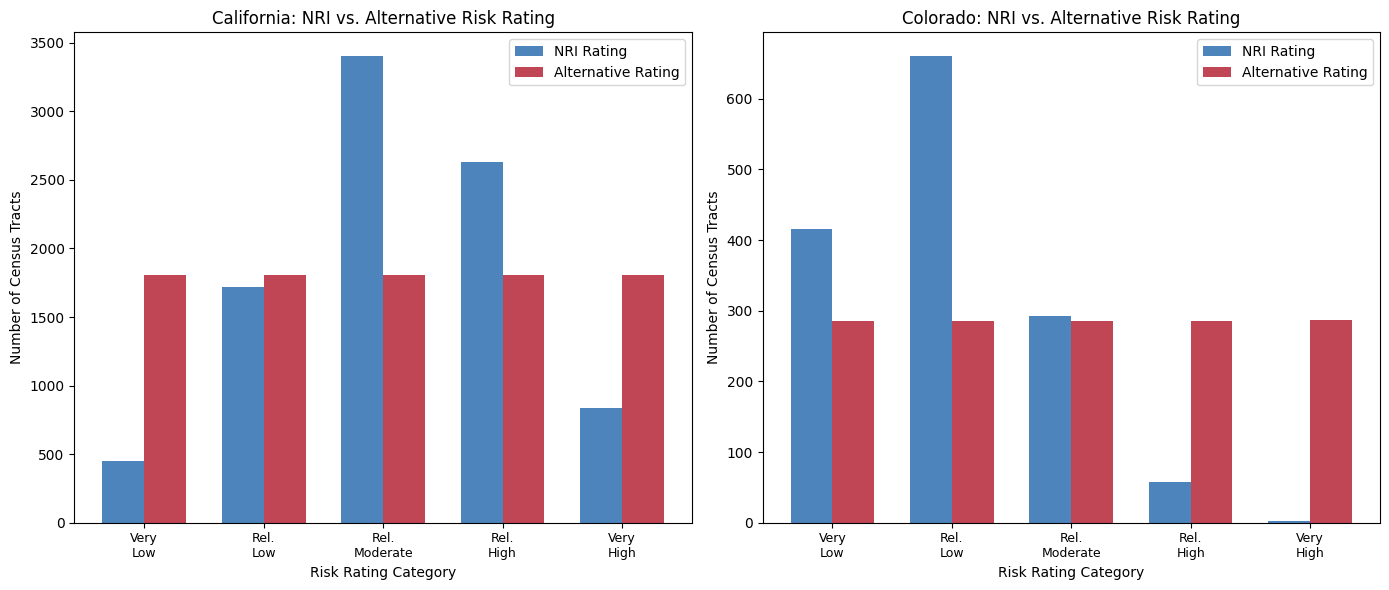

In [10]:
# Figure 1: Side-by-side bar chart comparing rating distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, title in [(axes[0], ca_valid, 'California'),
                         (axes[1], co_valid, 'Colorado')]:
    nri_counts = data['RISK_RATNG'].value_counts().reindex(
        rating_order, fill_value=0)
    alt_counts = data['ALT_RISK_RATNG'].value_counts().reindex(
        rating_order, fill_value=0)
    x = np.arange(len(rating_order))
    width = 0.35
    ax.bar(x - width/2, nri_counts.values, width,
           label='NRI Rating', color='#2166ac', alpha=0.8)
    ax.bar(x + width/2, alt_counts.values, width,
           label='Alternative Rating', color='#b2182b', alpha=0.8)
    ax.set_xlabel('Risk Rating Category')
    ax.set_ylabel('Number of Census Tracts')
    ax.set_title(f'{title}: NRI vs. Alternative Risk Rating')
    ax.set_xticks(x)
    ax.set_xticklabels(['Very\nLow', 'Rel.\nLow', 'Rel.\nModerate',
                        'Rel.\nHigh', 'Very\nHigh'], fontsize=9)
    ax.legend()

plt.tight_layout()
plt.savefig('fig1_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

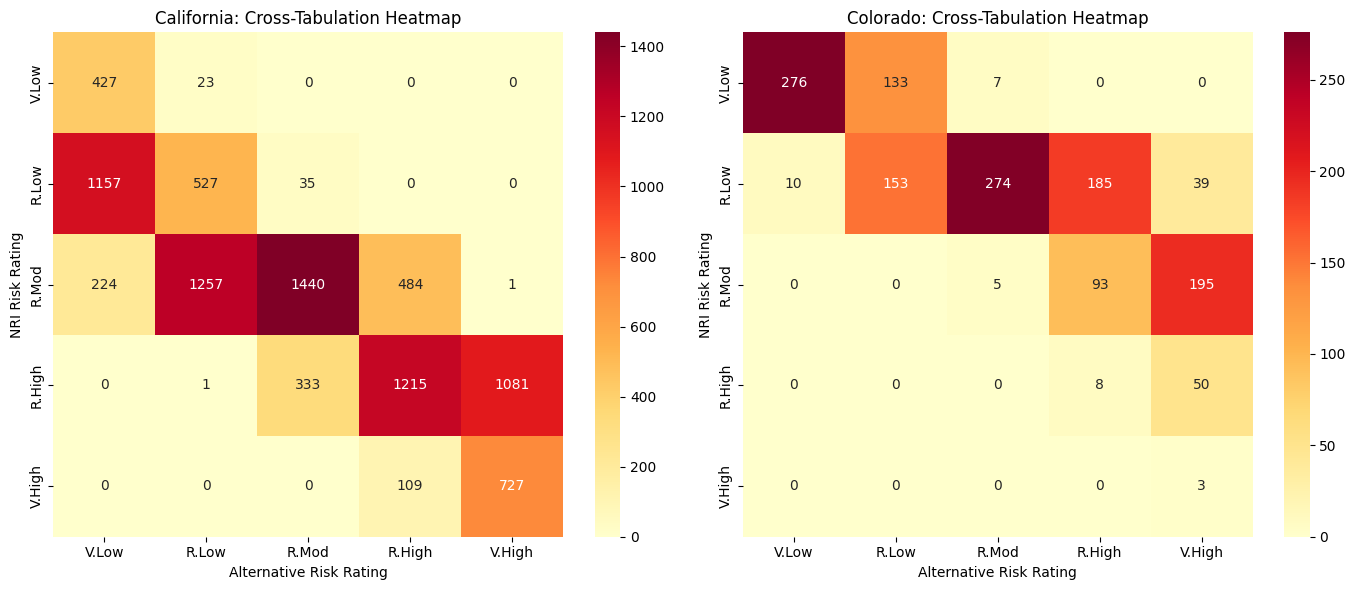

In [11]:
# Figure 2: Cross-tabulation heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
short_labels = ['V.Low', 'R.Low', 'R.Mod', 'R.High', 'V.High']

for ax, xtab, title in [(axes[0], ca_xtab, 'California'),
                         (axes[1], co_xtab, 'Colorado')]:
    inner = xtab.loc[rating_order, rating_order]
    sns.heatmap(inner, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
                xticklabels=short_labels, yticklabels=short_labels)
    ax.set_xlabel('Alternative Risk Rating')
    ax.set_ylabel('NRI Risk Rating')
    ax.set_title(f'{title}: Cross-Tabulation Heatmap')

plt.tight_layout()
plt.savefig('fig2_crosstab_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

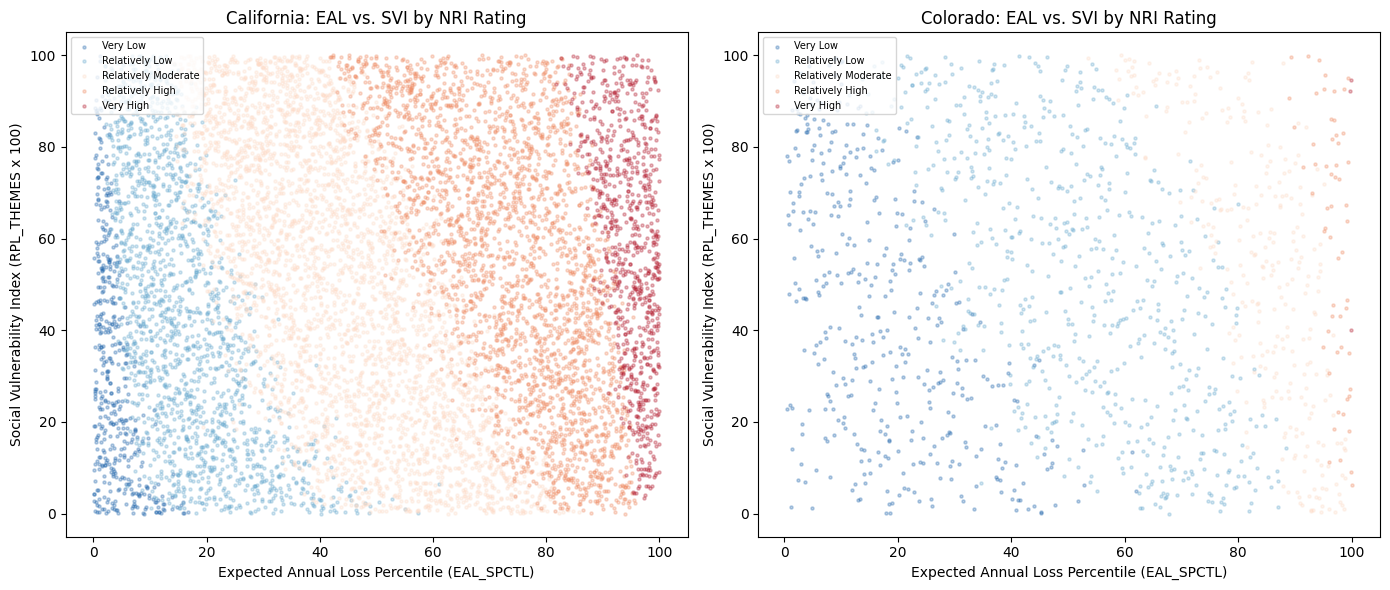

In [12]:
# Figure 3: EAL vs SVI scatter plot colored by NRI rating
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = {
    'Very Low': '#2166ac',
    'Relatively Low': '#67a9cf',
    'Relatively Moderate': '#fddbc7',
    'Relatively High': '#ef8a62',
    'Very High': '#b2182b'
}

for ax, data, title in [(axes[0], ca_valid, 'California'),
                         (axes[1], co_valid, 'Colorado')]:
    for rating in rating_order:
        subset = data[data['RISK_RATNG'] == rating]
        ax.scatter(subset['EAL_SPCTL'], subset['RPL_THEMES'] * 100,
                   c=colors[rating], label=rating, alpha=0.3, s=5)
    ax.set_xlabel('Expected Annual Loss Percentile (EAL_SPCTL)')
    ax.set_ylabel('Social Vulnerability Index (RPL_THEMES x 100)')
    ax.set_title(f'{title}: EAL vs. SVI by NRI Rating')
    ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig('fig3_eal_vs_svi.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8: Categorical Bias Analysis

In [13]:
# Quantify direction of disagreement
def rating_to_num(r, order=rating_order):
    return order.index(r) if r in order else -1

for label, data in [('California', ca_valid), ('Colorado', co_valid)]:
    data['NRI_NUM'] = data['RISK_RATNG'].apply(rating_to_num)
    data['ALT_NUM'] = data['ALT_RISK_RATNG'].apply(rating_to_num)
    upgraded = (data['ALT_NUM'] > data['NRI_NUM']).sum()
    downgraded = (data['ALT_NUM'] < data['NRI_NUM']).sum()
    same = (data['ALT_NUM'] == data['NRI_NUM']).sum()
    total = len(data)
    print(f"=== {label} ===")
    print(f"  Same category:  {same:>5} ({same/total*100:.1f}%)")
    print(f"  Upgraded (alt higher risk):   {upgraded:>5} "
          f"({upgraded/total*100:.1f}%)")
    print(f"  Downgraded (alt lower risk):  {downgraded:>5} "
          f"({downgraded/total*100:.1f}%)")
    print()

=== California ===
  Same category:   4336 (48.0%)
  Upgraded (alt higher risk):    1624 (18.0%)
  Downgraded (alt lower risk):   3081 (34.1%)

=== Colorado ===
  Same category:    445 (31.1%)
  Upgraded (alt higher risk):     976 (68.2%)
  Downgraded (alt lower risk):     10 (0.7%)



In [14]:
# County-level comparison for context
print("=== County-Level NRI Risk Rating ===")
print("\nCalifornia counties:")
print(county_ca['RISK_RATNG'].value_counts())
print(f"\nColorado counties:")
print(county_co['RISK_RATNG'].value_counts())
print("\nNote: County-level ratings differ significantly from")
print("Census Tract ratings, indicating geographic scale itself")
print("introduces categorical bias.")

=== County-Level NRI Risk Rating ===

California counties:
RISK_RATNG
Relatively High        21
Relatively Moderate    19
Very High               8
Relatively Low          8
Very Low                2
Name: count, dtype: int64

Colorado counties:
RISK_RATNG
Very Low               46
Relatively Low         10
Relatively Moderate     8
Name: count, dtype: int64

Note: County-level ratings differ significantly from
Census Tract ratings, indicating geographic scale itself
introduces categorical bias.


## Section 9: GeoPandas Mapping

The code below generates choropleth maps comparing NRI and alternative risk ratings.  
**Requirement:** The `Student Shape Files` folder must be in the working directory.

In [16]:
# Load national Census Tract shapefile (NRI Shapefile from FEMA)
import geopandas as gpd

print("Loading shapefile... this may take a few minutes.")
tracts = gpd.read_file('Student Shape Files')
print(f"Loaded {len(tracts)} tracts")

# Fix CRS: NRI shapefile is in Web Mercator (EPSG:3857)
if tracts.crs is None:
    tracts = tracts.set_crs(epsg=3857)
if tracts.crs.to_epsg() != 3857:
    tracts.crs = "EPSG:3857"

# Convert to Albers Equal Area for US mapping
tracts = tracts.to_crs("ESRI:102003")

# Replace -9999 with NaN
tracts = tracts.replace(-9999, np.nan)

Loading shapefile... this may take a few minutes.
Loaded 85154 tracts


In [17]:
# Merge alternative risk scores into shapefile
ca_alt = ca_valid[['TRACTFIPS', 'ALT_RISK_SCORE',
                   'ALT_RISK_PCTL', 'ALT_RISK_RATNG']].copy()
co_alt = co_valid[['TRACTFIPS', 'ALT_RISK_SCORE',
                   'ALT_RISK_PCTL', 'ALT_RISK_RATNG']].copy()
alt_all = pd.concat([ca_alt, co_alt], ignore_index=True)

# Merge into shapefile on TRACTFIPS
tracts['TRACTFIPS_INT'] = tracts['TRACTFIPS'].astype(float).astype('Int64')
tracts = tracts.merge(alt_all, left_on='TRACTFIPS_INT',
                      right_on='TRACTFIPS',
                      how='left', suffixes=('', '_ALT'))

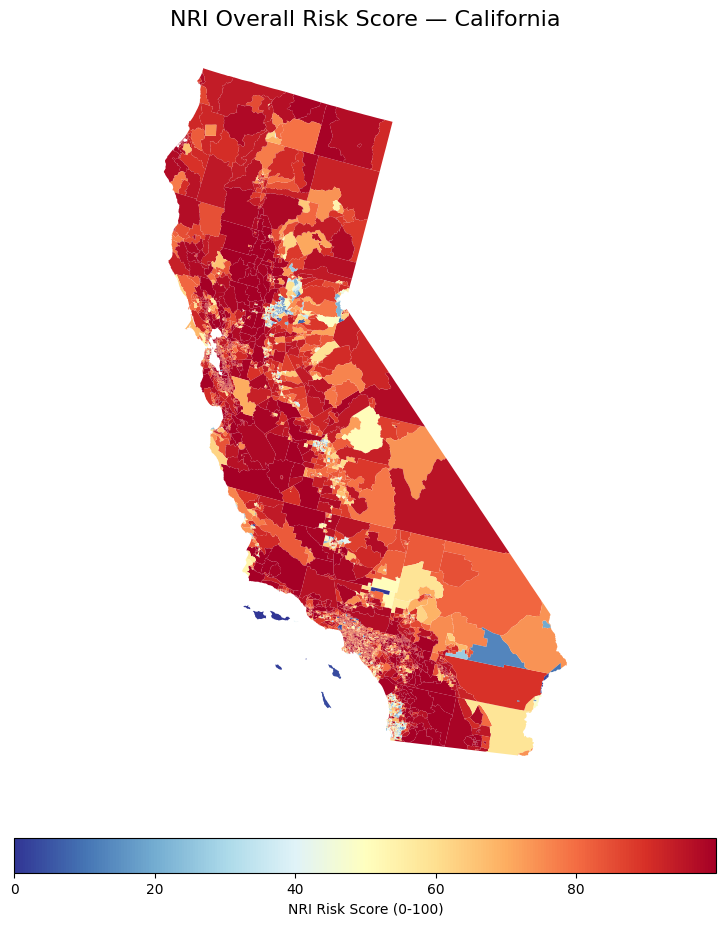

In [19]:
# Map 1: NRI Risk Score — California
state_map = tracts[tracts['STATE'] == 'California']

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map.plot(
    column='RISK_SCORE', ax=ax, legend=True, linewidth=0.0,
    cmap='RdYlBu_r',
    legend_kwds={'label': 'NRI Risk Score (0-100)',
                 'orientation': 'horizontal',
                 'shrink': 0.6, 'pad': 0.05},
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'})
ax.set_title("NRI Overall Risk Score — California", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('map1_ca_nri_risk.png', dpi=150, bbox_inches='tight')
plt.show()

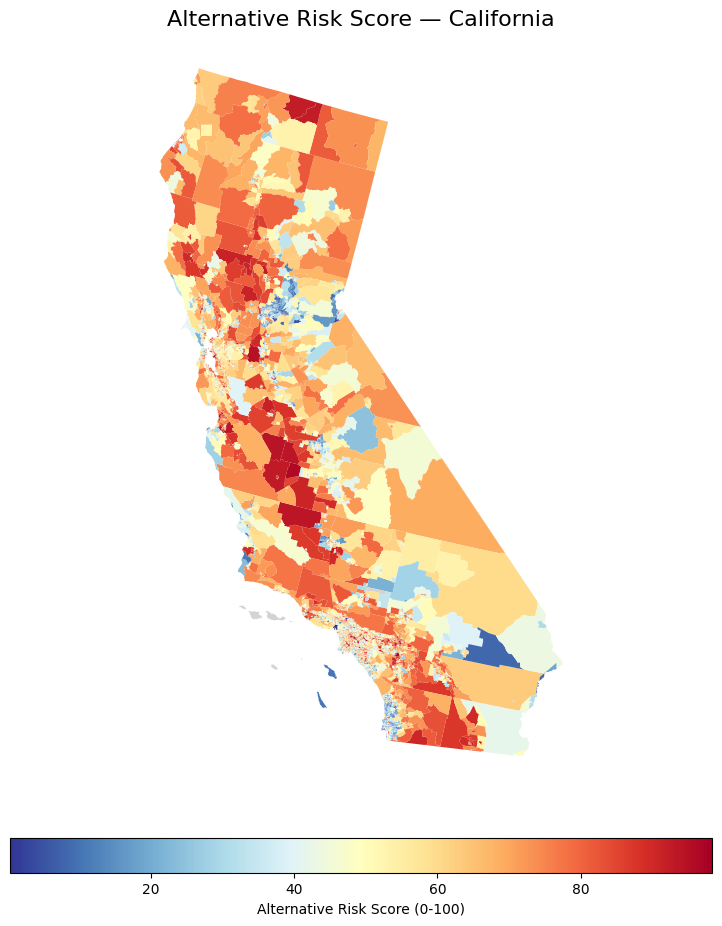

In [20]:
# Map 2: Alternative Risk Score — California
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map.plot(
    column='ALT_RISK_SCORE', ax=ax, legend=True, linewidth=0.0,
    cmap='RdYlBu_r',
    legend_kwds={'label': 'Alternative Risk Score (0-100)',
                 'orientation': 'horizontal',
                 'shrink': 0.6, 'pad': 0.05},
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'})
ax.set_title("Alternative Risk Score — California", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('map2_ca_alt_risk.png', dpi=150, bbox_inches='tight')
plt.show()

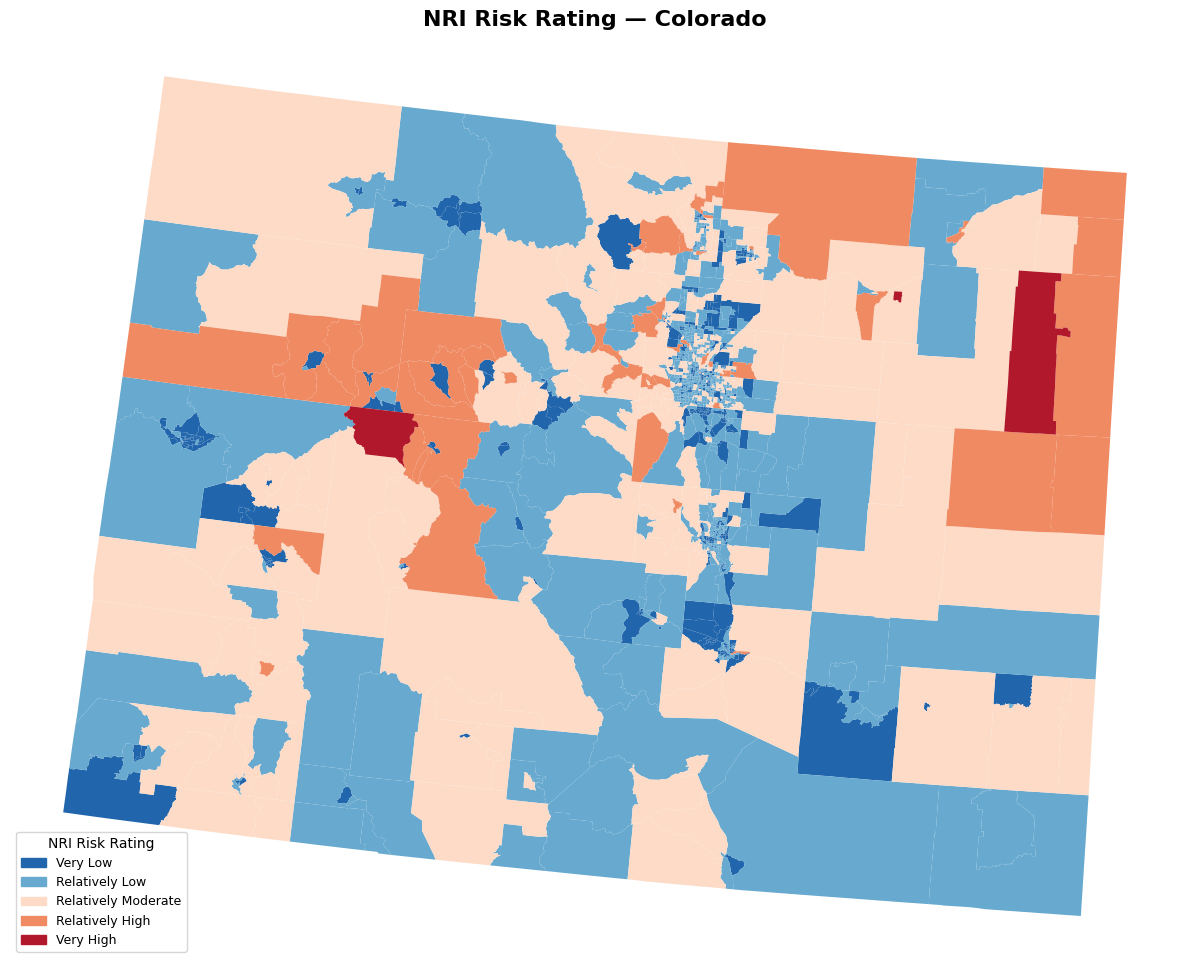

In [21]:
# Map 3: NRI Risk Rating Choropleth — Colorado
rating_colors = {
    "Very Low": "#2166ac",
    "Relatively Low": "#67a9cf",
    "Relatively Moderate": "#fddbc7",
    "Relatively High": "#ef8a62",
    "Very High": "#b2182b",
}

state_map = tracts[tracts['STATE'] == 'Colorado']
rated = state_map[state_map['RISK_RATNG'].isin(rating_order)]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
for rating in rating_order:
    subset = rated[rated['RISK_RATNG'] == rating]
    if not subset.empty:
        subset.plot(ax=ax, color=rating_colors[rating], linewidth=0.0)

handles = [mpatches.Patch(color=rating_colors[r], label=r)
           for r in rating_order]
ax.legend(handles=handles, title="NRI Risk Rating",
          loc="lower left", fontsize=9)
ax.set_title("NRI Risk Rating — Colorado",
             fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig('map3_co_nri_rating.png', dpi=150, bbox_inches='tight')
plt.show()

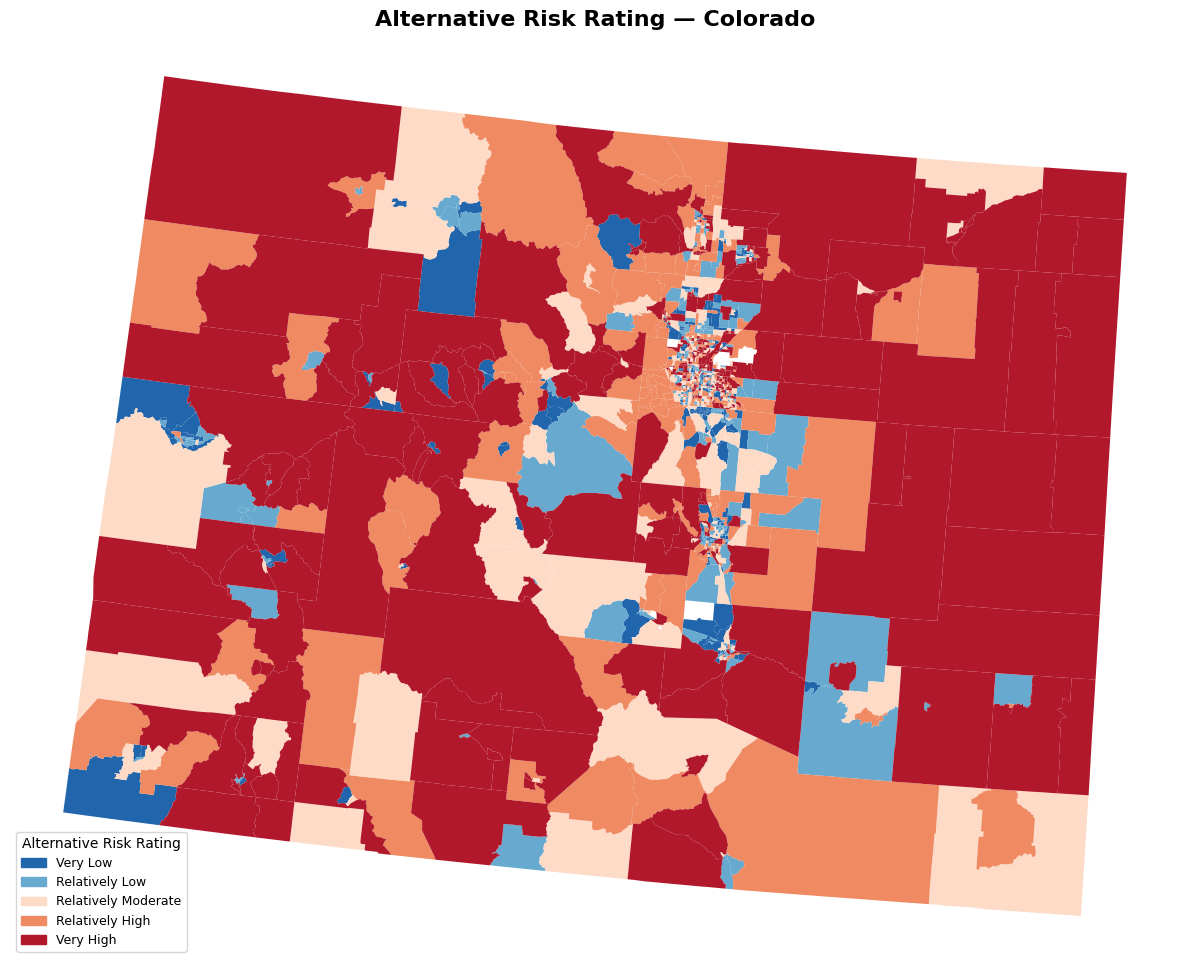

In [22]:
# Map 4: Alternative Risk Rating Choropleth — Colorado
rated = state_map[state_map['ALT_RISK_RATNG'].isin(rating_order)]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
for rating in rating_order:
    subset = rated[rated['ALT_RISK_RATNG'] == rating]
    if not subset.empty:
        subset.plot(ax=ax, color=rating_colors[rating], linewidth=0.0)

handles = [mpatches.Patch(color=rating_colors[r], label=r)
           for r in rating_order]
ax.legend(handles=handles, title="Alternative Risk Rating",
          loc="lower left", fontsize=9)
ax.set_title("Alternative Risk Rating — Colorado",
             fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig('map4_co_alt_rating.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 10: Export Cleaned Data

In [23]:
# Save cleaned and merged datasets
ca_valid.to_csv('California_NRI_SVI_Merged_Clean.csv', index=False)
co_valid.to_csv('Colorado_NRI_SVI_Merged_Clean.csv', index=False)
print("Cleaned datasets exported.")
print(f"  California: {len(ca_valid)} tracts")
print(f"  Colorado:   {len(co_valid)} tracts")

Cleaned datasets exported.
  California: 9041 tracts
  Colorado:   1431 tracts
